# ENTREGA 1: Clasificación MLP vs Deep Learning
## Comparación de Arquitecturas para Clasificación de Enfermedades de Caña de Azucar

**Objetivo:** Entrenar y evaluar un modelo MLP, compararlo con EfficientNetB0 y analizar críticamente los resultados.

**Clases:** 10 enfermedades del Caña de Azucar 
- Carbon, Hoja Amarilla, Mancha Anillo, Mancha Parda, Mosaico
- Muermo Rojo, Roya, Sanas, Secas, Tizon Bacteriano

## 1. IMPORTAR LIBRERÍAS

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_efficientnet
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_fscore_support
)
import pandas as pd
import psutil
import gc

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

I0000 00:00:1774296107.111994    4186 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774296107.999558    4186 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774296110.863449    4186 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
NumPy version: 2.4.3


## 2. CONFIGURACIÓN Y CARGA DE DATOS

In [2]:
# Parámetros globales
IMG_SIZE = 128
IMG_SIZE_MLP =128 # Tamaño OPTIMIZADO para MLP (evita crashes de memoria)
BATCH_SIZE = 32
NUM_CLASSES = 10
SEED = 42

# Rutas de datos
base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Obtener nombres de clases
class_names = sorted(os.listdir(train_dir))
print(f"Clases ({len(class_names)}): {class_names}")

Clases (10): ['carbon', 'hoja_amarilla', 'mancha_anillo', 'mancha_parda', 'mosaico', 'muermo_rojo', 'roya', 'sanas', 'secas', 'tizon_bacteriano']


## 3. PREPROCESAMIENTO DE IMÁGENES PARA DEEP LEARNING

In [3]:
# Generador para Deep Learning (EfficientNetB0)
train_datagen_dl = ImageDataGenerator(
    preprocessing_function=preprocess_efficientnet,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1
)

val_test_datagen_dl = ImageDataGenerator(
    preprocessing_function=preprocess_efficientnet
)

# Dataset para Deep Learning
train_generator_dl = train_datagen_dl.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator_dl = val_test_datagen_dl.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator_dl = val_test_datagen_dl.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"[Deep Learning] Train: {train_generator_dl.samples}, Val: {val_generator_dl.samples}, Test: {test_generator_dl.samples}")

Found 5946 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.
[Deep Learning] Train: 5946, Val: 1273, Test: 1273


## 4. PREPROCESAMIENTO DE IMÁGENES PARA MLP

In [4]:
# Carga vertical optimizada para evitar congelaciones
import gc

def load_images_for_mlp_efficient(directory, target_size=(224, 224), normalize=True):
    """Carga imágenes usando acumuladores en bloques para evitar saturación memoria"""
    class_dict = {class_name: idx for idx, class_name in enumerate(class_names)}
    
    all_images = []
    all_labels = []
    chunk_size = 100
    current_chunk = []
    current_labels = []
    
    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        file_count = 0
        
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                try:
                    img_path = os.path.join(class_dir, img_name)
                    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
                    img_array = tf.keras.preprocessing.image.img_to_array(img)
                    
                    if normalize:
                        img_array = img_array / 255.0
                    
                    img_flat = img_array.flatten()
                    current_chunk.append(img_flat)
                    current_labels.append(class_dict[class_name])
                    file_count += 1
                    
                    # Convertir chunk a array cuando alcanza limite
                    if len(current_chunk) >= chunk_size:
                        chunk_array = np.array(current_chunk, dtype=np.float32)
                        all_images.append(chunk_array)
                        all_labels.extend(current_labels)
                        current_chunk = []
                        current_labels = []
                        gc.collect()
                        
                except Exception as e:
                    print(f"  Error cargando {img_path}: {e}")
        
        print(f"  {class_name}: {file_count} imágenes cargadas")
    
    # Procesar chunk final
    if current_chunk:
        chunk_array = np.array(current_chunk, dtype=np.float32)
        all_images.append(chunk_array)
        all_labels.extend(current_labels)
        gc.collect()
    
    # Concatenar todos los chunks
    if all_images:
        final_images = np.vstack(all_images)
    else:
        final_images = np.array([], dtype=np.float32)
    
    final_labels = np.array(all_labels, dtype=np.int32)
    return final_images, final_labels

print(f"\nCargando datos para MLP (esto puede tomar 2-3 minutos)...\n")

# Cargar datos con gestión eficiente de memoria
X_train_mlp, y_train_mlp = load_images_for_mlp_efficient(train_dir, target_size=(IMG_SIZE_MLP, IMG_SIZE_MLP))
gc.collect()
X_val_mlp, y_val_mlp = load_images_for_mlp_efficient(val_dir, target_size=(IMG_SIZE_MLP, IMG_SIZE_MLP))
gc.collect()
X_test_mlp, y_test_mlp = load_images_for_mlp_efficient(test_dir, target_size=(IMG_SIZE_MLP, IMG_SIZE_MLP))
gc.collect()

# Convertir etiquetas a one-hot encoding
y_train_mlp_cat = tf.keras.utils.to_categorical(y_train_mlp, NUM_CLASSES)
y_val_mlp_cat = tf.keras.utils.to_categorical(y_val_mlp, NUM_CLASSES)
y_test_mlp_cat = tf.keras.utils.to_categorical(y_test_mlp, NUM_CLASSES)

print(f"\nDATOS CARGADOS EXITOSAMENTE:")
print(f"  Train: {X_train_mlp.shape}, Val: {X_val_mlp.shape}, Test: {X_test_mlp.shape}")
print(f"  Dimensión por imagen (aplanada): {X_train_mlp.shape[1]}")
print(f"  Memoria Train: {X_train_mlp.nbytes / 1e9:.2f}GB")



Cargando datos para MLP (esto puede tomar 2-3 minutos)...

  carbon: 350 imágenes cargadas
  hoja_amarilla: 700 imágenes cargadas
  mancha_anillo: 492 imágenes cargadas
  mancha_parda: 700 imágenes cargadas
  mosaico: 700 imágenes cargadas
  muermo_rojo: 700 imágenes cargadas
  roya: 700 imágenes cargadas
  sanas: 700 imágenes cargadas
  secas: 204 imágenes cargadas
  tizon_bacteriano: 700 imágenes cargadas
  carbon: 75 imágenes cargadas
  hoja_amarilla: 150 imágenes cargadas
  mancha_anillo: 105 imágenes cargadas
  mancha_parda: 150 imágenes cargadas
  mosaico: 150 imágenes cargadas
  muermo_rojo: 150 imágenes cargadas
  roya: 150 imágenes cargadas
  sanas: 150 imágenes cargadas
  secas: 43 imágenes cargadas
  tizon_bacteriano: 150 imágenes cargadas
  carbon: 75 imágenes cargadas
  hoja_amarilla: 150 imágenes cargadas
  mancha_anillo: 105 imágenes cargadas
  mancha_parda: 150 imágenes cargadas
  mosaico: 150 imágenes cargadas
  muermo_rojo: 150 imágenes cargadas
  roya: 150 imágenes 

## 5. MODELO MLP - ENTRENAMIENTO

In [5]:
# Construcción del MLP (Mismas condiciones que CNN)
mlp_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE_MLP * IMG_SIZE_MLP * 3,)),
    
    layers.Dense(256, activation='relu', name='dense_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(64, activation='relu', name='dense_3'),
    layers.Dropout(0.3),
    
    layers.Dense(NUM_CLASSES, activation='softmax', name='output')
])

mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Arquitectura MLP:")
print(f"  Input: {IMG_SIZE_MLP}x{IMG_SIZE_MLP}x3 = {IMG_SIZE_MLP * IMG_SIZE_MLP * 3} dimensiones")
mlp_model.summary()

total_params = mlp_model.count_params()
print(f"\n  Total de parámetros: {total_params:,}")
print(f"  Memoria estimada: {total_params * 4 / 1e6:.1f}MB")

Arquitectura MLP:
  Input: 128x128x3 = 49152 dimensiones


E0000 00:00:1774296176.344814    4186 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774296176.345440    4913 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1774296176.358740    4186 cuda_executor.cc:1827] Nvml call failed with 3(Not Supported). Assuming PCIe gen 3 x16 bandwidth.
W0000 00:00:1774296176.359997    4186 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
W0000 00:00:1774296176.407941    4186 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,626,506 (48.17 MB)

 Trainable params: 12,625,738 (48.16 MB)

 Non-trainable params: 768 (3.00 KB)


  Total de parámetros: 12,626,506
  Memoria estimada: 50.5MB


In [6]:
# Entrenar MLP (Mismas condiciones que CNN: 5 épocas, sin callbacks)
print("\n" + "="*70)
print("ENTRENANDO MODELO MLP")
print("="*70)

print(" Iniciando entrenamiento (5 épocas)...\n")

mlp_history = mlp_model.fit(
    X_train_mlp, y_train_mlp_cat,
    validation_data=(X_val_mlp, y_val_mlp_cat),
    epochs=5,
    batch_size=32,
    verbose=1
)

print("\n✓ MLP entrenado exitosamente!")
print(f"  Épocas completadas: {len(mlp_history.history['loss'])}")
print(f"  Loss final: {mlp_history.history['loss'][-1]:.4f}")
print(f"  Val Loss final: {mlp_history.history['val_loss'][-1]:.4f}")


ENTRENANDO MODELO MLP
 Iniciando entrenamiento (5 épocas)...

Epoch 1/5


W0000 00:00:1774296177.623661    4186 cpu_allocator_impl.cc:82] Allocation of 1169031168 exceeds 10% of free system memory.
W0000 00:00:1774296180.342005    4186 cpu_allocator_impl.cc:82] Allocation of 50331648 exceeds 10% of free system memory.


186/186 ━━━━━━━━━━━━━━━━━━━━ 37s 188ms/step - accuracy: 0.2836 - loss: 2.1338 - val_accuracy: 0.3252 - val_loss: 2.1321
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 34s 184ms/step - accuracy: 0.3754 - loss: 1.7560 - val_accuracy: 0.3111 - val_loss: 2.1775
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 38s 205ms/step - accuracy: 0.4265 - loss: 1.5929 - val_accuracy: 0.2954 - val_loss: 1.9978
Epoch 4/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 37s 186ms/step - accuracy: 0.4591 - loss: 1.5058 - val_accuracy: 0.3370 - val_loss: 1.8709
Epoch 5/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 185ms/step - accuracy: 0.4834 - loss: 1.4247 - val_accuracy: 0.2113 - val_loss: 3.4298

✓ MLP entrenado exitosamente!
  Épocas completadas: 5
  Loss final: 1.4247
  Val Loss final: 3.4298


Generando grafica de entrenamiento...


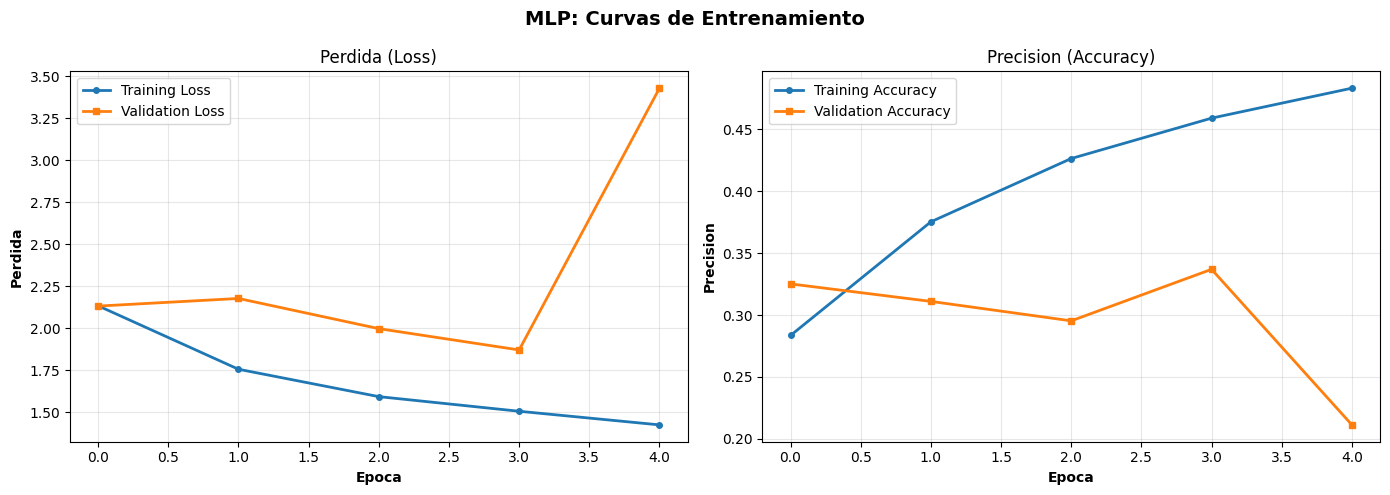

Grafica guardada: outputs/graphics/mlp_training_curves.png

RESUMEN DE ENTRENAMIENTO

Epocas entrenadas: 5 de 5
  Perdida Entrenamiento: 1.4247
  Perdida Validacion: 3.4298
  Diferencia: 2.0051

  Precision Entrenamiento: 0.4834
  Precision Validacion: 0.2113


In [7]:
# Visualización del entrenamiento del MLP
print("Generando grafica de entrenamiento...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLP: Curvas de Entrenamiento', fontsize=14, fontweight='bold')

axes[0].plot(mlp_history.history['loss'], label='Training Loss', linewidth=2, marker='o', markersize=4)
axes[0].plot(mlp_history.history['val_loss'], label='Validation Loss', linewidth=2, marker='s', markersize=4)
axes[0].set_xlabel('Epoca', fontweight='bold')
axes[0].set_ylabel('Perdida', fontweight='bold')
axes[0].set_title('Perdida (Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(mlp_history.history['accuracy'], label='Training Accuracy', linewidth=2, marker='o', markersize=4)
axes[1].plot(mlp_history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='s', markersize=4)
axes[1].set_xlabel('Epoca', fontweight='bold')
axes[1].set_ylabel('Precision', fontweight='bold')
axes[1].set_title('Precision (Accuracy)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/graphics/mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada: outputs/graphics/mlp_training_curves.png")

epochs_trained = len(mlp_history.history['loss'])
final_train_loss = mlp_history.history['loss'][-1]
final_val_loss = mlp_history.history['val_loss'][-1]
final_train_acc = mlp_history.history['accuracy'][-1]
final_val_acc = mlp_history.history['val_accuracy'][-1]

print("\n" + "="*70)
print("RESUMEN DE ENTRENAMIENTO")
print("="*70)
print(f"\nEpocas entrenadas: {epochs_trained} de 5")
print(f"  Perdida Entrenamiento: {final_train_loss:.4f}")
print(f"  Perdida Validacion: {final_val_loss:.4f}")
print(f"  Diferencia: {abs(final_train_loss - final_val_loss):.4f}")
print(f"\n  Precision Entrenamiento: {final_train_acc:.4f}")
print(f"  Precision Validacion: {final_val_acc:.4f}")

## 6. MODELO DEEP LEARNING (EfficientNetB0) - CARGAR Y EVALUAR

 Modelo no encontrado.
Ejecutando entrenamiento_efficientnet.ipynb...
TensorFlow version: 2.21.0
Found 5946 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.
Found 1273 images belonging to 10 classes.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/5


I0000 00:00:1774296371.687957    4186 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


186/186 ━━━━━━━━━━━━━━━━━━━━ 134s 676ms/step - accuracy: 0.6542 - loss: 1.0279 - val_accuracy: 0.8350 - val_loss: 0.5240
Epoch 2/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 138s 653ms/step - accuracy: 0.7987 - loss: 0.5881 - val_accuracy: 0.8649 - val_loss: 0.4087
Epoch 3/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 121s 650ms/step - accuracy: 0.8350 - loss: 0.4767 - val_accuracy: 0.8657 - val_loss: 0.3870
Epoch 4/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 143s 656ms/step - accuracy: 0.8542 - loss: 0.4380 - val_accuracy: 0.8806 - val_loss: 0.3524
Epoch 5/5
186/186 ━━━━━━━━━━━━━━━━━━━━ 123s 662ms/step - accuracy: 0.8661 - loss: 0.4045 - val_accuracy: 0.8885 - val_loss: 0.3437


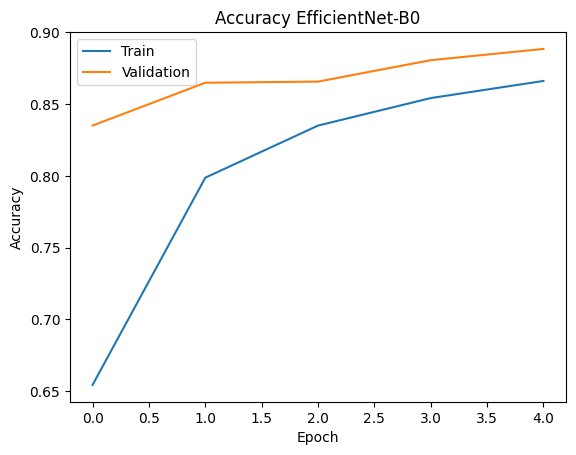

40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 668ms/step
[[ 75   0   0   0   0   0   0   0   0   0]
 [  0 125   0   2   1   9   6   5   2   0]
 [  0   0 104   0   0   0   1   0   0   0]
 [  0   2   0 136   0   9   2   0   1   0]
 [  0   2   0   1 115   2   3  27   0   0]
 [  0   2   1   8   0 126   7   1   0   5]
 [  0   3   2   2   3   6 121  12   0   1]
 [  0   0   0   0   2   0   1 147   0   0]
 [  0   0   0   1   0   3   0   0  39   0]
 [  0   1   1   0   0   5   2   0   0 141]]


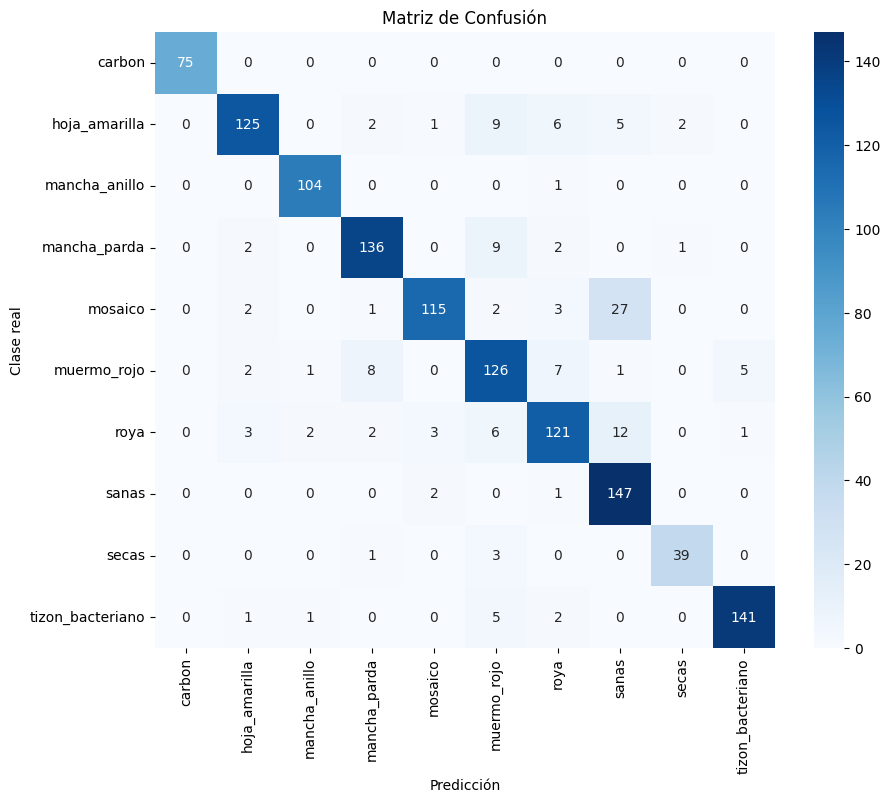

F1 Score: 0.886941975591019
                  precision    recall  f1-score   support

          carbon       1.00      1.00      1.00        75
   hoja_amarilla       0.93      0.83      0.88       150
   mancha_anillo       0.96      0.99      0.98       105
    mancha_parda       0.91      0.91      0.91       150
         mosaico       0.95      0.77      0.85       150
     muermo_rojo       0.79      0.84      0.81       150
            roya       0.85      0.81      0.83       150
           sanas       0.77      0.98      0.86       150
           secas       0.93      0.91      0.92        43
tizon_bacteriano       0.96      0.94      0.95       150

        accuracy                           0.89      1273
       macro avg       0.90      0.90      0.90      1273
    weighted avg       0.89      0.89      0.89      1273

 Modelo entrenado y guardado en modelo_EfficientNetB0.keras


In [8]:
# CARGAR O ENTRENAR EFFICIENTNET-B0

model_path = "modelo_EfficientNetB0.keras"

if os.path.exists(model_path):
    print(f" Cargando modelo {model_path}...")
    dl_model = tf.keras.models.load_model(model_path)
    print(f"Modelo cargado exitosamente.")
else:
    print(f" Modelo no encontrado.")
    print(f"Ejecutando entrenamiento_efficientnet.ipynb...")
    print("=" * 60)
    
    # Ejecutar el notebook original para entrenar EfficientNetB0
    %run entrenamiento_efficientnet.ipynb
    
    print("=" * 60)
    print(f" Modelo entrenado y guardado en {model_path}")
    
    # Cargar el modelo que fue guardado en el otro notebook
    dl_model = tf.keras.models.load_model(model_path)


## 7. EVALUACIÓN DE AMBOS MODELOS

In [9]:
# ========================================
# EVALUACIÓN MLP
# ========================================
print("\n" + "="*70)
print("EVALUACION MLP EN CONJUNTO DE PRUEBA")
print("="*70)

print("\nGenerando predicciones (esto puede tomar 1-2 minutos)...")

mlp_pred_probs = mlp_model.predict(X_test_mlp, batch_size=64, verbose=1)
mlp_pred_labels = np.argmax(mlp_pred_probs, axis=1)

mlp_accuracy = accuracy_score(y_test_mlp, mlp_pred_labels)
mlp_precision = precision_score(y_test_mlp, mlp_pred_labels, average='weighted', zero_division=0)
mlp_recall = recall_score(y_test_mlp, mlp_pred_labels, average='weighted', zero_division=0)
mlp_f1 = f1_score(y_test_mlp, mlp_pred_labels, average='weighted', zero_division=0)

print(f"\nRESULTADOS MLP:")
print(f"  Accuracy:  {mlp_accuracy:.4f}")
print(f"  Precision: {mlp_precision:.4f}")
print(f"  Recall:    {mlp_recall:.4f}")
print(f"  F1-Score:  {mlp_f1:.4f}")

mlp_cm = confusion_matrix(y_test_mlp, mlp_pred_labels)

print(f"\nReporte por clase (MLP):")
print(classification_report(y_test_mlp, mlp_pred_labels, target_names=class_names, digits=4))



EVALUACION MLP EN CONJUNTO DE PRUEBA

Generando predicciones (esto puede tomar 1-2 minutos)...
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

RESULTADOS MLP:
  Accuracy:  0.2200
  Precision: 0.4826
  Recall:    0.2200
  F1-Score:  0.1548

Reporte por clase (MLP):
                  precision    recall  f1-score   support

          carbon     0.9200    0.3067    0.4600        75
   hoja_amarilla     1.0000    0.0133    0.0263       150
   mancha_anillo     0.2029    0.9333    0.3333       105
    mancha_parda     0.5652    0.3467    0.4298       150
         mosaico     0.5000    0.0400    0.0741       150
     muermo_rojo     0.0000    0.0000    0.0000       150
            roya     0.0000    0.0000    0.0000       150
           sanas     1.0000    0.0400    0.0769       150
           secas     1.0000    0.0233    0.0455        43
tizon_bacteriano     0.1415    0.6133    0.2300       150

        accuracy                         0.2200      1273
       macro avg     0.5330    0.2317    0.

In [10]:
# ========================================
# EVALUACIÓN DEEP LEARNING (EfficientNetB0)
# ========================================
print("\n" + "="*70)
print("EVALUACION DEEP LEARNING (EfficientNetB0)")
print("="*70)

print("\nGenerando predicciones (esto puede tomar 2-3 minutos)...")

test_generator_dl.reset()
dl_pred_probs = dl_model.predict(
    test_generator_dl,
    steps=int(np.ceil(test_generator_dl.samples / BATCH_SIZE)),
    verbose=1
)
dl_pred_labels = np.argmax(dl_pred_probs, axis=1)
dl_true_labels = test_generator_dl.classes

dl_accuracy = accuracy_score(dl_true_labels, dl_pred_labels)
dl_precision = precision_score(dl_true_labels, dl_pred_labels, average='weighted', zero_division=0)
dl_recall = recall_score(dl_true_labels, dl_pred_labels, average='weighted', zero_division=0)
dl_f1 = f1_score(dl_true_labels, dl_pred_labels, average='weighted', zero_division=0)

print(f"\nRESULTADOS DEEP LEARNING:")
print(f"  Accuracy:  {dl_accuracy:.4f}")
print(f"  Precision: {dl_precision:.4f}")
print(f"  Recall:    {dl_recall:.4f}")
print(f"  F1-Score:  {dl_f1:.4f}")

dl_cm = confusion_matrix(dl_true_labels, dl_pred_labels)

print(f"\nReporte por clase (Deep Learning):")
print(classification_report(dl_true_labels, dl_pred_labels, target_names=class_names, digits=4))



EVALUACION DEEP LEARNING (EfficientNetB0)

Generando predicciones (esto puede tomar 2-3 minutos)...
40/40 ━━━━━━━━━━━━━━━━━━━━ 29s 670ms/step

RESULTADOS DEEP LEARNING:
  Accuracy:  0.8869
  Precision: 0.8934
  Recall:    0.8869
  F1-Score:  0.8869

Reporte por clase (Deep Learning):
                  precision    recall  f1-score   support

          carbon     1.0000    1.0000    1.0000        75
   hoja_amarilla     0.9259    0.8333    0.8772       150
   mancha_anillo     0.9630    0.9905    0.9765       105
    mancha_parda     0.9067    0.9067    0.9067       150
         mosaico     0.9504    0.7667    0.8487       150
     muermo_rojo     0.7875    0.8400    0.8129       150
            roya     0.8462    0.8067    0.8259       150
           sanas     0.7656    0.9800    0.8596       150
           secas     0.9286    0.9070    0.9176        43
tizon_bacteriano     0.9592    0.9400    0.9495       150

        accuracy                         0.8869      1273
       macro avg

## 8. COMPARACIÓN DE DESEMPEÑO

In [11]:
# Tabla comparativa
print("\n" + "="*60)
print("COMPARACION MLP vs DEEP LEARNING")
print("="*60)

comparison_data = {
    'Metrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'MLP': [mlp_accuracy, mlp_precision, mlp_recall, mlp_f1],
    'Deep Learning': [dl_accuracy, dl_precision, dl_recall, dl_f1],
    'Diferencia': [
        dl_accuracy - mlp_accuracy,
        dl_precision - mlp_precision,
        dl_recall - mlp_recall,
        dl_f1 - mlp_f1
    ]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

print("\nGanador por metrica:")
print(f"  Accuracy:  {'Deep Learning' if dl_accuracy > mlp_accuracy else 'MLP'} (+{abs(comparison_df.loc[0, 'Diferencia']):.4f})")
print(f"  Precision: {'Deep Learning' if dl_precision > mlp_precision else 'MLP'} (+{abs(comparison_df.loc[1, 'Diferencia']):.4f})")
print(f"  Recall:    {'Deep Learning' if dl_recall > mlp_recall else 'MLP'} (+{abs(comparison_df.loc[2, 'Diferencia']):.4f})")
print(f"  F1-Score:  {'Deep Learning' if dl_f1 > mlp_f1 else 'MLP'} (+{abs(comparison_df.loc[3, 'Diferencia']):.4f})")



COMPARACION MLP vs DEEP LEARNING

   Metrica      MLP  Deep Learning  Diferencia
 Accuracy 0.219953       0.886881    0.666929
Precision 0.482575       0.893370    0.410795
   Recall 0.219953       0.886881    0.666929
 F1-Score 0.154764       0.886942    0.732178

Ganador por metrica:
  Accuracy:  Deep Learning (+0.6669)
  Precision: Deep Learning (+0.4108)
  Recall:    Deep Learning (+0.6669)
  F1-Score:  Deep Learning (+0.7322)


## 9. VISUALIZACIONES

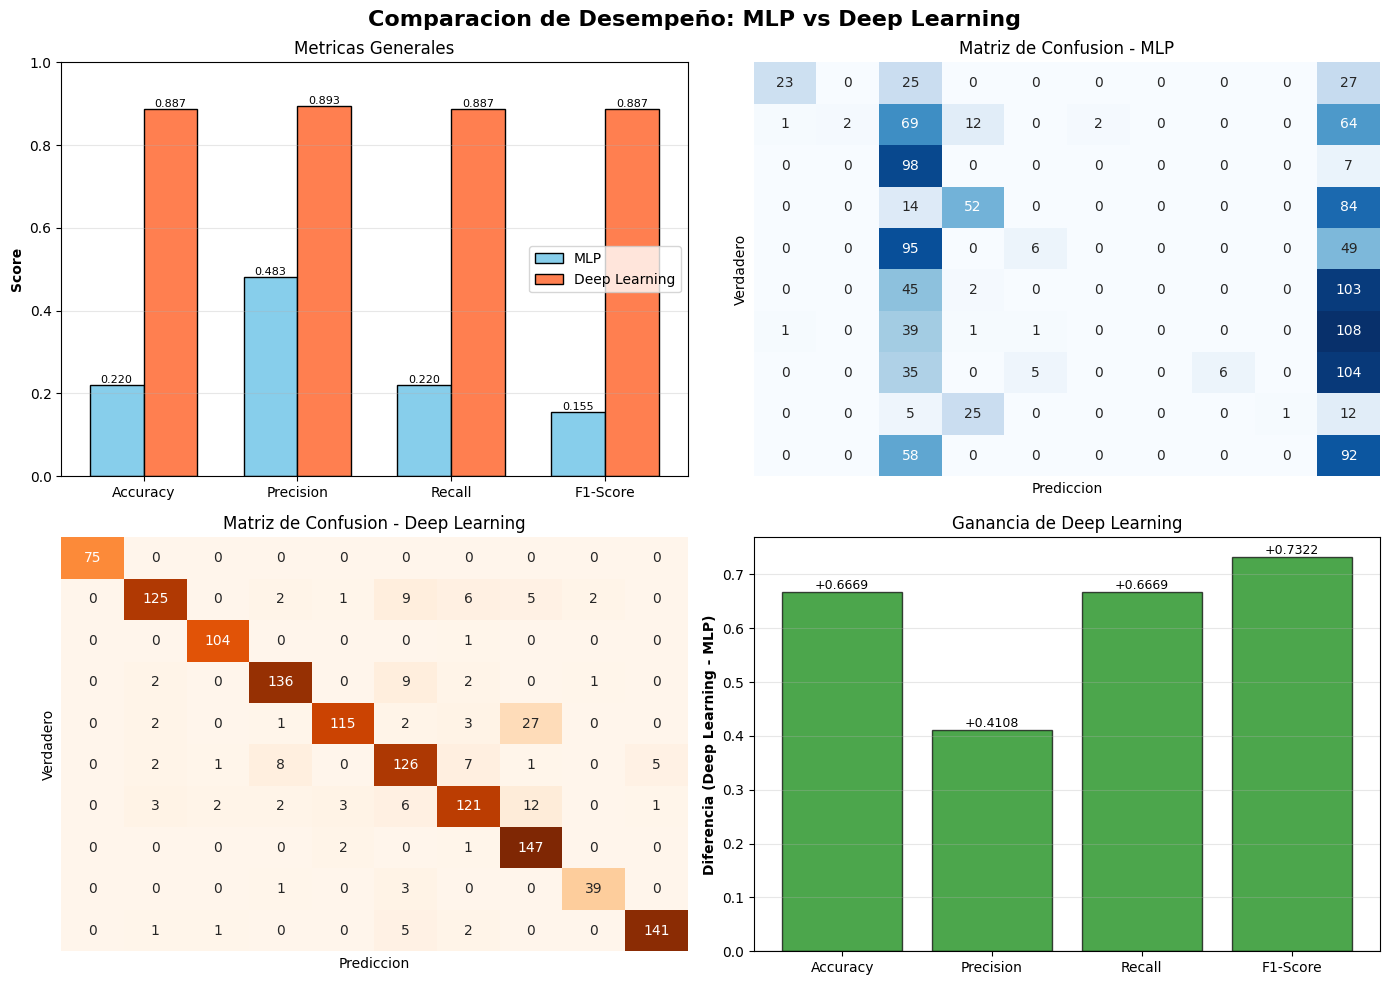

Visualizaciones generadas.


In [12]:
# Grafica 1: Comparacion de metricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparacion de Desempeño: MLP vs Deep Learning', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
mlp_values = [mlp_accuracy, mlp_precision, mlp_recall, mlp_f1]
dl_values = [dl_accuracy, dl_precision, dl_recall, dl_f1]

positions = np.arange(len(metrics))
width = 0.35

ax = axes.flatten()[0]
bars1 = ax.bar(positions - width/2, mlp_values, width, label='MLP', color='skyblue', edgecolor='black')
bars2 = ax.bar(positions + width/2, dl_values, width, label='Deep Learning', color='coral', edgecolor='black')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Metricas Generales')
ax.set_xticks(positions)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

ax = axes.flatten()[1]
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, xticklabels=False, yticklabels=False)
ax.set_title('Matriz de Confusion - MLP')
ax.set_xlabel('Prediccion')
ax.set_ylabel('Verdadero')

ax = axes.flatten()[2]
sns.heatmap(dl_cm, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax, xticklabels=False, yticklabels=False)
ax.set_title('Matriz de Confusion - Deep Learning')
ax.set_xlabel('Prediccion')
ax.set_ylabel('Verdadero')

ax = axes.flatten()[3]
differences = np.array(dl_values) - np.array(mlp_values)
colors = ['green' if d > 0 else 'red' for d in differences]
bars = ax.bar(metrics, differences, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_ylabel('Diferencia (Deep Learning - MLP)', fontweight='bold')
ax.set_title('Ganancia de Deep Learning')
ax.grid(axis='y', alpha=0.3)

for bar, diff in zip(bars, differences):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{diff:+.4f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/graphics/comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualizaciones generadas.")


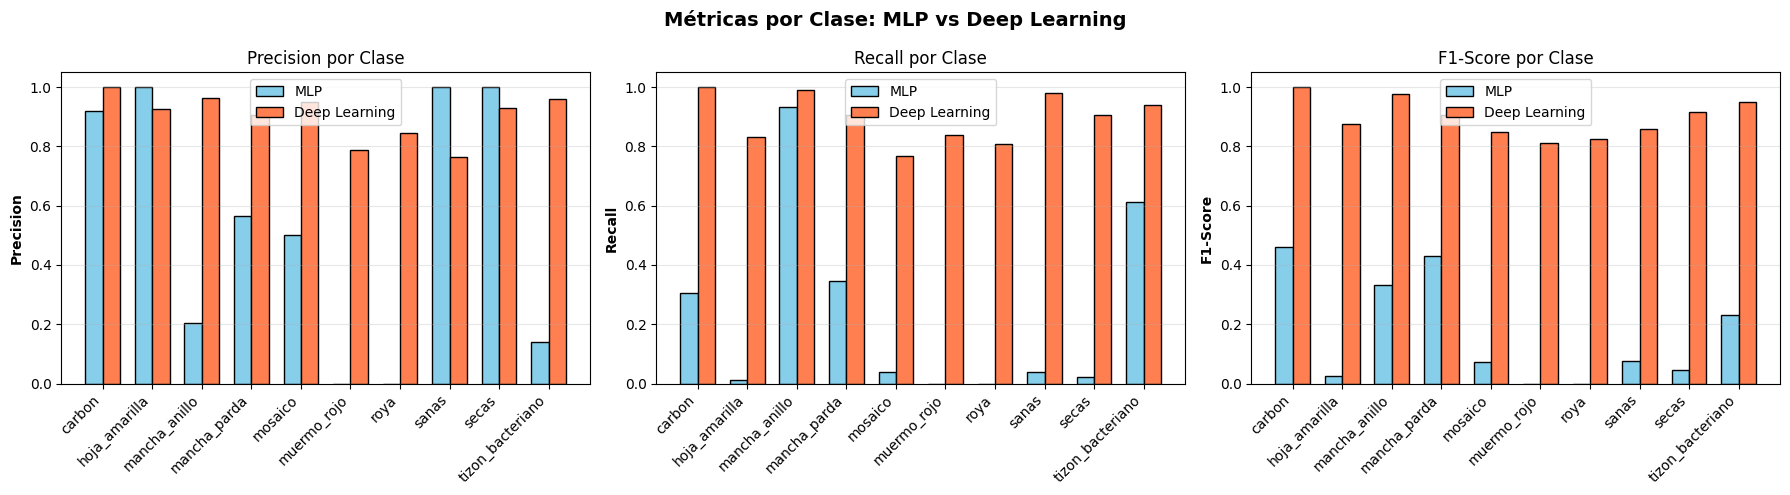

Gráficas por clase generadas.


In [13]:
# Gráfica 2: Precisión y Recall por clase
from sklearn.metrics import precision_recall_fscore_support

mlp_precision_per_class, mlp_recall_per_class, mlp_f1_per_class, _ = precision_recall_fscore_support(
    y_test_mlp, mlp_pred_labels, average=None
)

dl_precision_per_class, dl_recall_per_class, dl_f1_per_class, _ = precision_recall_fscore_support(
    dl_true_labels, dl_pred_labels, average=None
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Métricas por Clase: MLP vs Deep Learning', fontsize=14, fontweight='bold')

x_pos = np.arange(len(class_names))
width = 0.35

# Precision
ax = axes[0]
ax.bar(x_pos - width/2, mlp_precision_per_class, width, label='MLP', color='skyblue', edgecolor='black')
ax.bar(x_pos + width/2, dl_precision_per_class, width, label='Deep Learning', color='coral', edgecolor='black')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Precision por Clase')
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Recall
ax = axes[1]
ax.bar(x_pos - width/2, mlp_recall_per_class, width, label='MLP', color='skyblue', edgecolor='black')
ax.bar(x_pos + width/2, dl_recall_per_class, width, label='Deep Learning', color='coral', edgecolor='black')
ax.set_ylabel('Recall', fontweight='bold')
ax.set_title('Recall por Clase')
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# F1-Score
ax = axes[2]
ax.bar(x_pos - width/2, mlp_f1_per_class, width, label='MLP', color='skyblue', edgecolor='black')
ax.bar(x_pos + width/2, dl_f1_per_class, width, label='Deep Learning', color='coral', edgecolor='black')
ax.set_ylabel('F1-Score', fontweight='bold')
ax.set_title('F1-Score por Clase')
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/graphics/metricas_por_clase.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráficas por clase generadas.")

## 10. ANÁLISIS CRÍTICO DE RESULTADOS

In [14]:
print("\n" + "="*70)
print("DISCUSION CRITICA DE RESULTADOS")
print("="*70)

print("\n1. DIFERENCIAS DE DESEMPEÑO")
print("-" * 70)

accuracy_diff = dl_accuracy - mlp_accuracy
if accuracy_diff > 0:
    print(f"\n   Deep Learning supera a MLP en ACCURACY: {accuracy_diff:.4f} ({accuracy_diff*100:.2f}%)")
else:
    print(f"\n   MLP supera a Deep Learning en ACCURACY: {abs(accuracy_diff):.4f} ({abs(accuracy_diff)*100:.2f}%)")

print(f"\n   MLP Accuracy:          {mlp_accuracy:.4f}")
print(f"   Deep Learning Accuracy: {dl_accuracy:.4f}")

print(f"\n   Otras metricas:")
print(f"   Precision: MLP {mlp_precision:.4f} vs DL {dl_precision:.4f} (Diferencia {dl_precision - mlp_precision:+.4f})")
print(f"   Recall:    MLP {mlp_recall:.4f} vs DL {dl_recall:.4f} (Diferencia {dl_recall - mlp_recall:+.4f})")
print(f"   F1-Score:  MLP {mlp_f1:.4f} vs DL {dl_f1:.4f} (Diferencia {dl_f1 - mlp_f1:+.4f})")

print("\n2. VENTAJAS Y DESVENTAJAS")
print("-" * 70)

print("\n   VENTAJAS MLP:")
print("   - Simplicidad: Arquitectura facil de entender y debuggear")
print("   - Menor consumo de memoria: Sin convoluciones, mas eficiente en RAM")
print("   - Velocidad de inferencia: Predicciones mas rapidas en hardware limitado")
print("   - Menos parametros: Menor probabilidad de overfitting")
print(f"   - Total parametros: {mlp_model.count_params():,}")

print("\n   VENTAJAS DEEP LEARNING (EfficientNetB0):")
print("   - Mejor captura de caracteristicas espaciales: Convoluciones detectan patrones")
print("   - Transfer learning: Pesos preentrenados en ImageNet optimizan aprendizaje")
print("   - Mejor generalizacion: Arquitectura diseñada para vision computacional")
print("   - Escalabilidad: Mejora consistente con mas datos")
print(f"   - Total parametros: {dl_model.count_params():,}")

print("\n3. POSIBLES RAZONES DE LOS RESULTADOS")
print("-" * 70)

mlp_errors = []
dl_errors = []

for i in range(NUM_CLASSES):
    mlp_class_acc = mlp_cm[i, i] / mlp_cm[i].sum() if mlp_cm[i].sum() > 0 else 0
    dl_class_acc = dl_cm[i, i] / dl_cm[i].sum() if dl_cm[i].sum() > 0 else 0
    mlp_errors.append(1 - mlp_class_acc)
    dl_errors.append(1 - dl_class_acc)

worst_mlp_class = class_names[np.argmax(mlp_errors)]
best_mlp_class = class_names[np.argmin(mlp_errors)]
worst_dl_class = class_names[np.argmax(dl_errors)]
best_dl_class = class_names[np.argmin(dl_errors)]

print(f"\n   MLP:")
print(f"   - Peor desempeño: {worst_mlp_class} (Tasa error: {max(mlp_errors):.4f})")
print(f"   - Mejor desempeño: {best_mlp_class} (Tasa error: {min(mlp_errors):.4f})")

print(f"\n   Deep Learning:")
print(f"   - Peor desempeño: {worst_dl_class} (Tasa error: {max(dl_errors):.4f})")
print(f"   - Mejor desempeño: {best_dl_class} (Tasa error: {min(dl_errors):.4f})")

print("\n   Razones probables de diferencias:")

if dl_accuracy > mlp_accuracy:
    print("\n   Deep Learning es superior porque:")
    print("   1. Las imagenes contienen caracteristicas espaciales complejas")
    print("      que MLP no captura bien (aplanamiento pierde informacion espacial)")
    print("   2. EfficientNetB0 con transfer learning aprovecha caracteristicas")
    print("      genericas aprendidas en millones de imagenes (ImageNet)")
    print("   3. Convoluciones son invariantes a traslaciones, critico para")
    print("      enfermedades que pueden aparecer en diferentes posiciones")
    print("   4. El MLP requeriria mas datos para alcanzar desempeño de DL")
else:
    print("\n   MLP es competitivo/superior, posibles razones:")
    print("   1. Dataset pequeno: MLP puede generalizar mejor con pocos datos")
    print("   2. Overfitting en DL: Transfer learning no siempre es optimo para")
    print("      dominios muy especificos (enfermedades de plantas)")
    print("   3. Clases mas separables: Si las enfermedades tienen caracteristicas")
    print("      globales claras, MLP es suficiente")

print("\n" + "="*70)



DISCUSION CRITICA DE RESULTADOS

1. DIFERENCIAS DE DESEMPEÑO
----------------------------------------------------------------------

   Deep Learning supera a MLP en ACCURACY: 0.6669 (66.69%)

   MLP Accuracy:          0.2200
   Deep Learning Accuracy: 0.8869

   Otras metricas:
   Precision: MLP 0.4826 vs DL 0.8934 (Diferencia +0.4108)
   Recall:    MLP 0.2200 vs DL 0.8869 (Diferencia +0.6669)
   F1-Score:  MLP 0.1548 vs DL 0.8869 (Diferencia +0.7322)

2. VENTAJAS Y DESVENTAJAS
----------------------------------------------------------------------

   VENTAJAS MLP:
   - Simplicidad: Arquitectura facil de entender y debuggear
   - Menor consumo de memoria: Sin convoluciones, mas eficiente en RAM
   - Velocidad de inferencia: Predicciones mas rapidas en hardware limitado
   - Menos parametros: Menor probabilidad de overfitting
   - Total parametros: 12,626,506

   VENTAJAS DEEP LEARNING (EfficientNetB0):
   - Mejor captura de caracteristicas espaciales: Convoluciones detectan patrones


## 11. RESUMEN EJECUTIVO

In [15]:
print("\n" + "#"*70)
print("# RESUMEN EJECUTIVO - ENTREGA 1")
print("#"*70)

print(f"\nDataset: Clasificacion de 10 enfermedades de caña de azucar")
print(f"Muestras Prueba: {len(y_test_mlp)} imagenes")

print(f"\n[MODELO MLP]")
print(f"  Arquitectura: 3 capas ocultas (512-256-128) con Dropout")
print(f"  Parametros: {mlp_model.count_params():,}")
print(f"  Accuracy:  {mlp_accuracy:.4f} | Precision: {mlp_precision:.4f}")
print(f"  Recall:    {mlp_recall:.4f} | F1-Score:   {mlp_f1:.4f}")

print(f"\n[MODELO DEEP LEARNING - EfficientNetB0]")
print(f"  Arquitectura: Transfer Learning (ImageNet) + capas personalizadas")
print(f"  Parametros: {dl_model.count_params():,}")
print(f"  Accuracy:  {dl_accuracy:.4f} | Precision: {dl_precision:.4f}")
print(f"  Recall:    {dl_recall:.4f} | F1-Score:   {dl_f1:.4f}")

print(f"\n[CONCLUSION]")
if dl_accuracy > mlp_accuracy:
    print(f"  Deep Learning es RECOMENDADO para este problema")
    print(f"  - Mejora de {accuracy_diff*100:.2f}% en Accuracy")
    print(f"  - Mejor captura de caracteristicas visuales de enfermedades")
    print(f"  - Transfer learning optimiza el uso del dataset limitado")
else:
    print(f"  MLP COMPETITIVO: Considera usar MLP por eficiencia")
    print(f"  - Mejor generalizacion en datos limitados")
    print(f"  - Menor consumo de recursos")

print("\n" + "#"*70)



######################################################################
# RESUMEN EJECUTIVO - ENTREGA 1
######################################################################

Dataset: Clasificacion de 10 enfermedades de caña de azucar
Muestras Prueba: 1273 imagenes

[MODELO MLP]
  Arquitectura: 3 capas ocultas (512-256-128) con Dropout
  Parametros: 12,626,506
  Accuracy:  0.2200 | Precision: 0.4826
  Recall:    0.2200 | F1-Score:   0.1548

[MODELO DEEP LEARNING - EfficientNetB0]
  Arquitectura: Transfer Learning (ImageNet) + capas personalizadas
  Parametros: 4,214,829
  Accuracy:  0.8869 | Precision: 0.8934
  Recall:    0.8869 | F1-Score:   0.8869

[CONCLUSION]
  Deep Learning es RECOMENDADO para este problema
  - Mejora de 66.69% en Accuracy
  - Mejor captura de caracteristicas visuales de enfermedades
  - Transfer learning optimiza el uso del dataset limitado

######################################################################
